# Clasificación de Razas de Perros y Gatos con CNN (Oxford-IIIT Pet Dataset)

## Informe técnico — Proyecto de Redes Neuronales Convolucionales

**Objetivo:** entrenar un clasificador capaz de reconocer 37 razas de perros y gatos a partir de imágenes, alcanzando una *accuracy* en el conjunto de test de al menos **85%**, sin evidencias de *overfitting* ni de *underfitting* en el modelo final seleccionado.

**Dataset:** [Oxford-IIIT Pet Dataset](https://www.robots.ox.ac.uk/~vgg/data/pets/) — 37 razas de perros y gatos, ~200 imágenes por clase, con alta variabilidad de escala, pose, iluminación, fondo y encuadre. Se accede a través de `tensorflow_datasets` (`oxford_iiit_pet`).

### Estructura del notebook

| Fase | Contenido |
|---|---|
| **Fase 1** | Exploración de datos (EDA), preparación (pipelines `tf.data`), infraestructura común (utilidades de entrenamiento/evaluación) |
| **Fase 2** | Modelos base: Fully Connected (sobre imágenes aplanadas) y CNN propia (arquitectura diseñada por el equipo) |
| **Fase 3** | Mejora de rendimiento: **ResNet18** residual entrenada desde cero, *transfer learning* con MobileNetV2 preentrenada y *fine-tuning* |
| **Fase 4** | Evaluación final, matriz de confusión, análisis visual de errores, comparación de los 5 modelos y despliegue |

### Configuración global

```
SEED        = 42
IMG_SIZE    = 160
BATCH_SIZE  = 32
NUM_CLASSES = 37
EPOCHS      = 40
split = ['train[:80%]', 'train[80%:90%]', 'train[90%:]']
```


In [13]:
# Ejecutar una vez al abrir el notebook, antes de importar TensorFlow.
import platform
import subprocess
import sys

if not (sys.version_info >= (3, 10) and sys.version_info < (3, 13)):
    raise RuntimeError("Este proyecto requiere Python 3.10, 3.11 o 3.12.")

system = platform.system()
if system == "Windows":
    raise RuntimeError(
        "Para usar GPU con TensorFlow en Windows, abre este notebook desde Ubuntu en WSL2 "
        "con los drivers NVIDIA para WSL instalados. Desde WSL2, la plataforma será Linux "
        "y esta celda instalará TensorFlow con CUDA."
    )

requirements = [
    "ipykernel",
    "numpy",
    "pandas",
    "matplotlib",
    "seaborn",
    "scikit-learn",
    "tensorflow-datasets==4.9.4",
    "tensorflow-metadata==1.15.0",
]

if system == "Darwin":
    if platform.machine() not in {"arm64", "aarch64"}:
        raise RuntimeError("La aceleración GPU de TensorFlow en macOS requiere Apple Silicon.")
    requirements.extend([
        "tensorflow-macos==2.16.2",
        "tensorflow-metal==1.1.0",
    ])
elif system == "Linux":
    requirements.append("tensorflow[and-cuda]==2.16.1")
else:
    raise RuntimeError(f"Sistema operativo no compatible: {system}")

subprocess.check_call([sys.executable, "-m", "pip", "install", *requirements])
print(f"Dependencias listas para {system}. Reinicia el kernel si TensorFlow ya estaba importado.")

Dependencias listas para Darwin. Reinicia el kernel si TensorFlow ya estaba importado.


In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
from tensorflow.keras import layers, models, callbacks, applications, optimizers
from sklearn.metrics import confusion_matrix, classification_report

# --- Configuración global reproducible ---
SEED = 42
IMG_SIZE = 160
BATCH_SIZE = 32
NUM_CLASSES = 37
EPOCHS = 40

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

# --- Forzar uso de GPU (obligatorio para este proyecto) ---
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print(f"GPUs disponibles: {len(gpus)}")

if not gpus:
    raise RuntimeError(
        "No se detectó ninguna GPU. Este notebook requiere GPU para entrenar en tiempos razonables "
        "(ResNet18 y transfer learning con MobileNetV2). Verifica los drivers/CUDA o el entorno de ejecución."
    )

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

tf.config.set_soft_device_placement(True)
print(f"Usando GPU: {gpus[0].name}")


TensorFlow: 2.16.2
GPUs disponibles: 1
Usando GPU: /physical_device:GPU:0


## Fase 1 — Exploración, Preparación de Datos e Infraestructura

Se carga el dataset `oxford_iiit_pet` desde `tensorflow_datasets`, usando la etiqueta `label` (37 razas). El dataset oficial solo trae particiones `train`/`test`; como se pide trabajar únicamente sobre `train` con una partición 80/10/10, se generan los splits `train[:80%]`, `train[80%:90%]` y `train[90%:]` para train/val/test respectivamente.


In [3]:
split = ["train[:80%]", "train[80%:90%]", "train[90%:]"]
DATA_DIR = os.path.join(os.getcwd(), "tensorflow_datasets")
os.makedirs(DATA_DIR, exist_ok=True)

(ds_train_raw, ds_val_raw, ds_test_raw), ds_info = tfds.load(
    "oxford_iiit_pet",
    split=split,
    with_info=True,
    as_supervised=True,
    data_dir=DATA_DIR,
)

class_names = ds_info.features["label"].names
print(f"Número de clases: {ds_info.features['label'].num_classes}")
print(f"Ejemplos train: {tf.data.experimental.cardinality(ds_train_raw).numpy()}")
print(f"Ejemplos val:   {tf.data.experimental.cardinality(ds_val_raw).numpy()}")
print(f"Ejemplos test:  {tf.data.experimental.cardinality(ds_test_raw).numpy()}")
print(f"Dataset local: {DATA_DIR}")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/3680 [00:00<?, ? examples/s]

Shuffling /Users/semadrig/Documents/Masters/Cognitive_Systems/Group_Project_CNN/tensorflow_datasets/oxford_iii…

Generating test examples...:   0%|          | 0/3669 [00:00<?, ? examples/s]

Shuffling /Users/semadrig/Documents/Masters/Cognitive_Systems/Group_Project_CNN/tensorflow_datasets/oxford_iii…

Dataset oxford_iiit_pet downloaded and prepared to /Users/semadrig/Documents/Masters/Cognitive_Systems/Group_Project_CNN/tensorflow_datasets/oxford_iiit_pet/3.2.0. Subsequent calls will reuse this data.
Número de clases: 37
Ejemplos train: 2944
Ejemplos val:   368
Ejemplos test:  368
Dataset local: /Users/semadrig/Documents/Masters/Cognitive_Systems/Group_Project_CNN/tensorflow_datasets


2026-09-10 13:43:43.982158: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-09-10 13:43:43.982466: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-09-10 13:43:43.982480: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-09-10 13:43:43.983046: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-09-10 13:43:43.983803: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
2026-09-10 13:52:28.013032: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


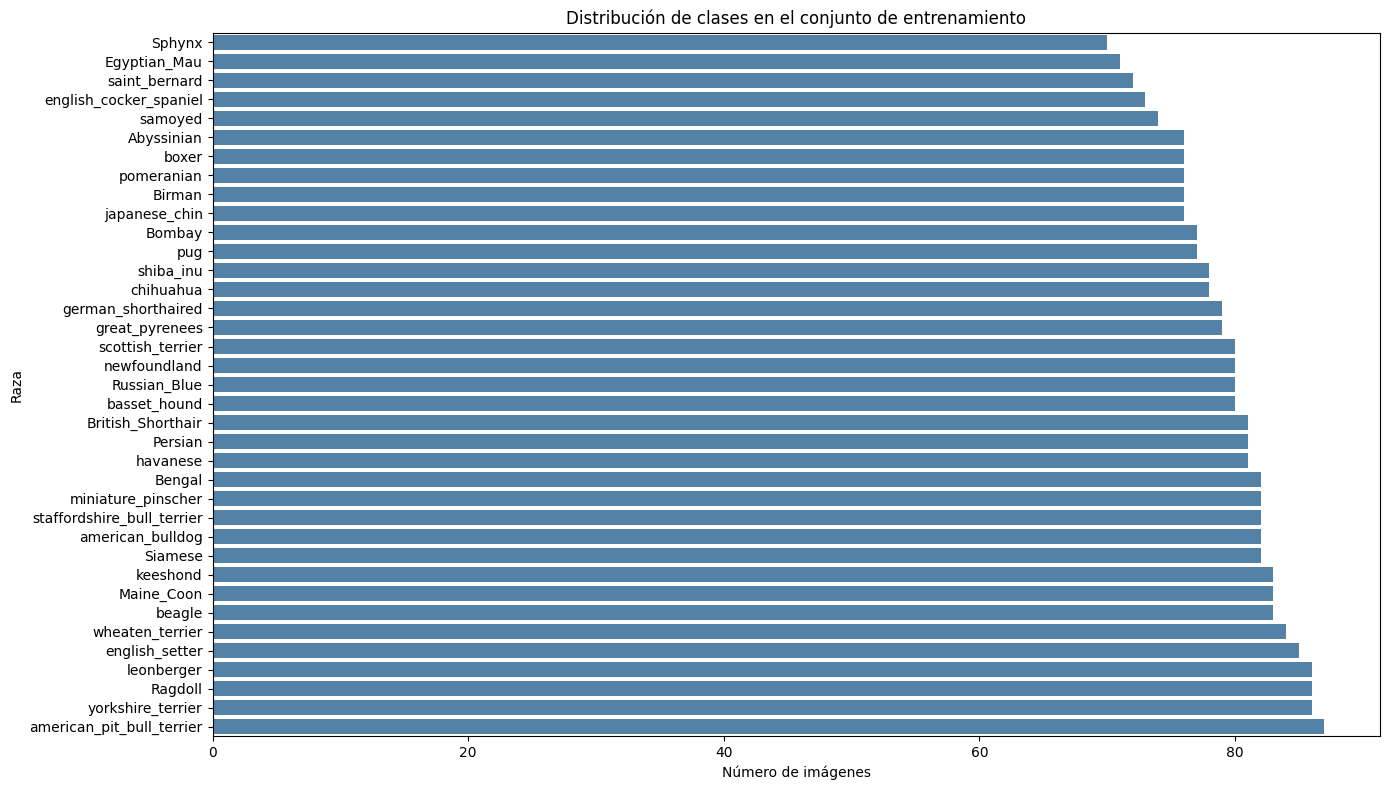

Mínimo por clase: 70  |  Máximo por clase: 87  |  Media: 79.6
Ratio desbalance (max/min): 1.24


In [4]:
# --- Distribución de clases (balance del dataset) ---
train_labels = np.array([label.numpy() for _, label in ds_train_raw])
counts = np.bincount(train_labels, minlength=NUM_CLASSES)

df_counts = pd.DataFrame({"raza": class_names, "n_train": counts}).sort_values("n_train")

plt.figure(figsize=(14, 8))
sns.barplot(data=df_counts, y="raza", x="n_train", color="steelblue")
plt.title("Distribución de clases en el conjunto de entrenamiento")
plt.xlabel("Número de imágenes")
plt.ylabel("Raza")
plt.tight_layout()
plt.show()

print(f"Mínimo por clase: {counts.min()}  |  Máximo por clase: {counts.max()}  |  Media: {counts.mean():.1f}")
print(f"Ratio desbalance (max/min): {counts.max() / counts.min():.2f}")


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
2026-09-10 13:52:36.020808: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


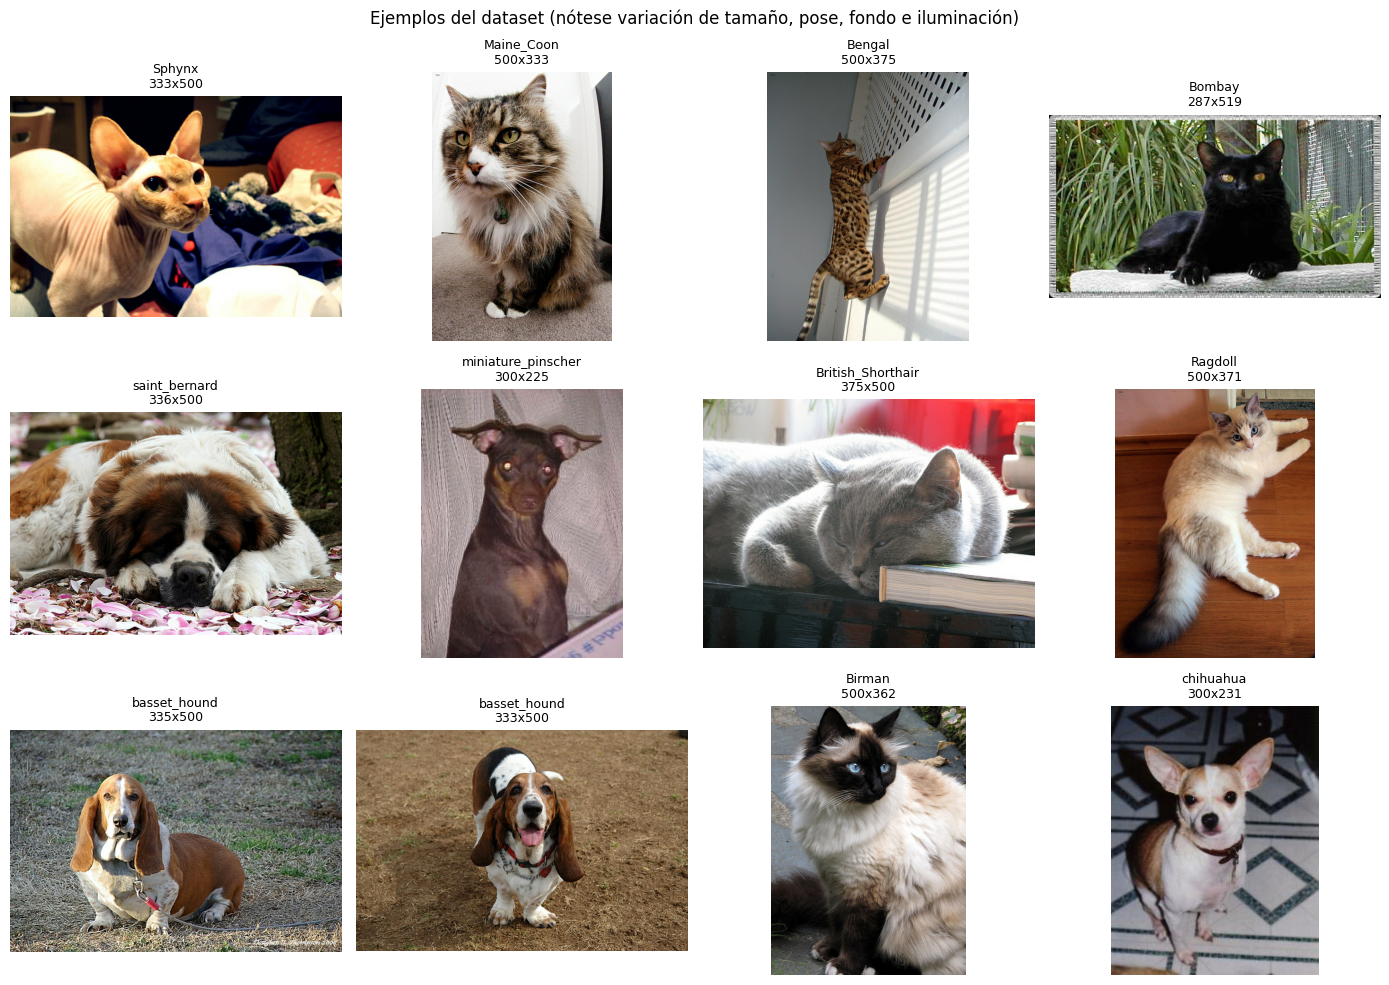

Alto - media/min/max: 384.27 150 1920
Ancho - media/min/max: 434.1166666666667 119 2560


2026-09-10 13:52:36.330735: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [5]:
# --- Ejemplos representativos y variabilidad de tamaños/aspect ratio ---
plt.figure(figsize=(14, 10))
for i, (image, label) in enumerate(ds_train_raw.shuffle(1000, seed=SEED).take(12)):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(image.numpy())
    plt.title(f"{class_names[label.numpy()]}\n{image.shape[0]}x{image.shape[1]}", fontsize=9)
    plt.axis("off")
plt.suptitle("Ejemplos del dataset (nótese variación de tamaño, pose, fondo e iluminación)")
plt.tight_layout()
plt.show()

# Estadísticas de tamaño de imagen sobre una muestra
sample_shapes = np.array([image.shape[:2] for image, _ in ds_train_raw.take(300)])
print("Alto - media/min/max:", sample_shapes[:, 0].mean(), sample_shapes[:, 0].min(), sample_shapes[:, 0].max())
print("Ancho - media/min/max:", sample_shapes[:, 1].mean(), sample_shapes[:, 1].min(), sample_shapes[:, 1].max())


### Pipelines `tf.data` y augmentation

Se define una única función de preprocesamiento (`resize` a `IMG_SIZE x IMG_SIZE` + normalización a `[0,1]`) y una capa de *data augmentation* (`RandomFlip`, `RandomRotation`, `RandomZoom`, `RandomContrast`) que solo se aplica sobre el split de entrenamiento. Estas capas se ejecutan dentro del grafo (`tf.keras.Sequential`), por lo que solo están activas cuando `training=True`, evitando afectar validación/test.


In [6]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label


data_augmentation = tf.keras.Sequential(
    [
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.08, seed=SEED),
        layers.RandomZoom(0.15, seed=SEED),
        layers.RandomContrast(0.15, seed=SEED),
    ],
    name="data_augmentation",
)


def make_dataset(ds_raw, shuffle=False, augment=False):
    ds = ds_raw.map(preprocess, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(1000, seed=SEED)
    ds = ds.batch(BATCH_SIZE)
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


# Datasets para los modelos CNN (con y sin augmentation en train)
train_ds_aug = make_dataset(ds_train_raw, shuffle=True, augment=True)
train_ds = make_dataset(ds_train_raw, shuffle=True, augment=False)
val_ds = make_dataset(ds_val_raw)
test_ds = make_dataset(ds_test_raw)

print("Batch de ejemplo:", next(iter(train_ds_aug))[0].shape)


2026-09-10 13:52:41.942011: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


Batch de ejemplo: (32, 160, 160, 3)


2026-09-10 13:52:42.228592: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node data_augmentation_1/random_rotation_1/Add/_22}}]] [type.googleapis.com/tensorflow.DerivedStatus='']
2026-09-10 13:52:42.228616: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: CANCELLED: RecvAsync is cancelled.
	 [[{{node data_augmentation_1/random_flip_1/ReadVariableOp/_4}}]] [type.googleapis.com/tensorflow.DerivedStatus='']


In [7]:
# --- Infraestructura común de entrenamiento/evaluación reutilizada en todas las fases ---
os.makedirs("checkpoints", exist_ok=True)
results = {}  # nombre_modelo -> dict con métricas e historial, para comparación final en Fase 4


def build_callbacks(name, patience=6, monitor="val_accuracy"):
    return [
        callbacks.EarlyStopping(monitor=monitor, mode="max", patience=patience, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
        callbacks.ModelCheckpoint(f"checkpoints/{name}.keras", monitor=monitor, mode="max", save_best_only=True),
    ]


def plot_history(history, title):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(hist["loss"], label="train")
    axes[0].plot(hist["val_loss"], label="val")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(hist["accuracy"], label="train")
    axes[1].plot(hist["val_accuracy"], label="val")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def train_and_evaluate(model, name, train_data, val_data, epochs=EPOCHS, extra_callbacks=None):
    cbs = build_callbacks(name) + (extra_callbacks or [])
    history = model.fit(train_data, validation_data=val_data, epochs=epochs, callbacks=cbs, verbose=2)
    plot_history(history, name)

    train_loss, train_acc = model.evaluate(train_data, verbose=0)
    val_loss, val_acc = model.evaluate(val_data, verbose=0)
    test_loss, test_acc = model.evaluate(test_ds, verbose=0)

    results[name] = {
        "history": history.history,
        "train_acc": train_acc, "train_loss": train_loss,
        "val_acc": val_acc, "val_loss": val_loss,
        "test_acc": test_acc, "test_loss": test_loss,
        "model": model,
    }
    print(f"\n[{name}] train_acc={train_acc:.3f}  val_acc={val_acc:.3f}  test_acc={test_acc:.3f}  "
          f"gap(train-val)={train_acc - val_acc:.3f}")
    return history


## Fase 2 — Modelo Base (Baseline) y Bucle de Entrenamiento

Se entrena un modelo base:

**CNN propia**: arquitectura convolucional diseñada por el equipo (bloques Conv2D + BatchNorm + MaxPooling + Dropout), entrenada con *data augmentation*, usando la infraestructura común de entrenamiento (`train_and_evaluate`).


In [8]:
# --- Modelo 2: CNN propia (arquitectura diseñada por el equipo) ---
def build_custom_cnn():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = inputs
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
        x = layers.Dropout(0.25)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
    return models.Model(inputs, outputs, name="custom_cnn")


custom_cnn = build_custom_cnn()
custom_cnn.compile(optimizer=optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
custom_cnn.summary()


Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 160, 160, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160, 160, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 80, 80, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 80, 80, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 40, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 40, 40, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,251,397 (4.77 MB)

 Trainable params: 1,249,477 (4.77 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [9]:
# Entrenamiento con augmentation (ayuda a un modelo con más capacidad a generalizar)
train_and_evaluate(custom_cnn, "custom_cnn", train_ds_aug, val_ds)


Epoch 1/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


92/92 - 20s - 222ms/step - accuracy: 0.0319 - loss: 4.0515 - val_accuracy: 0.0326 - val_loss: 5.1036 - learning_rate: 0.0010
Epoch 2/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


92/92 - 12s - 132ms/step - accuracy: 0.0462 - loss: 3.8330 - val_accuracy: 0.0353 - val_loss: 4.7727 - learning_rate: 0.0010
Epoch 3/40


...

92/92 - 12s - 135ms/step - accuracy: 0.0577 - loss: 3.8876 - val_accuracy: 0.0435 - val_loss: 4.1962 - learning_rate: 0.0010
Epoch 7/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


92/92 - 13s - 142ms/step - accuracy: 0.0598 - loss: 3.8095 - val_accuracy: 0.0761 - val_loss: 3.9071 - learning_rate: 0.0010
Epoch 8/40


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment


KeyboardInterrupt: 

**Análisis Fase 2:** compare la brecha train-vs-val (`gap`) impresa arriba. Un `gap` grande y `val_accuracy` estancada temprano (mientras `train_accuracy` sigue subiendo) es evidencia de *overfitting*; un `train_accuracy` bajo que no mejora es evidencia de *underfitting*. Se espera que la CNN propia obtenga una accuracy razonable, aunque probablemente aún no alcance el 85% objetivo — lo que motiva la Fase 3.


## Fase 3 — Mejora de Rendimiento (ResNet18, Transfer Learning y Ajuste Fino)

Se exploran tres estrategias adicionales:

3. **ResNet18 residual entrenada desde cero**: arquitectura propuesta con bloques residuales (*skip connections*), implementada manualmente con Keras Functional API (Keras no incluye ResNet18/34 en `keras.applications`, solo variantes ≥50 capas).
4. **Transfer learning**: `MobileNetV2` preentrenada en ImageNet, con la base congelada y un nuevo *head* de clasificación.
5. **Fine-tuning**: se descongelan las capas superiores de `MobileNetV2` y se reentrena con una tasa de aprendizaje baja para adaptar los filtros a este dominio.


In [ ]:
# --- Modelo 3: ResNet18 (CNN residual) construida desde cero ---
def conv_bn(x, filters, kernel_size, strides=1, activation="relu"):
    x = layers.Conv2D(filters, kernel_size, strides=strides, padding="same",
                       use_bias=False, kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    if activation:
        x = layers.Activation(activation)(x)
    return x


def basic_residual_block(x, filters, strides=1):
    shortcut = x
    y = conv_bn(x, filters, 3, strides=strides)
    y = conv_bn(y, filters, 3, strides=1, activation=None)
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = conv_bn(shortcut, filters, 1, strides=strides, activation=None)
    out = layers.Add()([shortcut, y])
    return layers.Activation("relu")(out)


def build_resnet18(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = conv_bn(inputs, 64, 7, strides=2)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding="same")(x)

    # 4 etapas x 2 bloques residuales básicos = 18 capas con peso (ResNet18)
    stage_config = [(64, 1), (128, 2), (256, 2), (512, 2)]
    for filters, first_stride in stage_config:
        x = basic_residual_block(x, filters, strides=first_stride)
        x = basic_residual_block(x, filters, strides=1)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return models.Model(inputs, outputs, name="resnet18_scratch")


resnet18 = build_resnet18()
resnet18.compile(optimizer=optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
resnet18.summary()


In [ ]:
train_and_evaluate(resnet18, "resnet18_scratch", train_ds_aug, val_ds)


In [ ]:
# --- Modelo 4: Transfer Learning con MobileNetV2 (base congelada) ---
base_model = applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights="imagenet"
)
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# nuestro pipeline ya normaliza a [0,1]; MobileNetV2 espera [-1,1]
x = layers.Rescaling(2.0, offset=-1.0)(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
transfer_model = models.Model(inputs, outputs, name="mobilenetv2_transfer")

transfer_model.compile(optimizer=optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
transfer_model.summary()


In [ ]:
train_and_evaluate(transfer_model, "mobilenetv2_transfer", train_ds_aug, val_ds, epochs=20)


In [ ]:
# --- Modelo 5: Fine-tuning — descongelar capas superiores de MobileNetV2 ---
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 40  # descongelar solo el último bloque de capas

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

transfer_model.compile(
    optimizer=optimizers.Adam(1e-5),  # LR muy baja para no destruir los pesos preentrenados
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
transfer_model.summary()


In [ ]:
train_and_evaluate(transfer_model, "mobilenetv2_finetuned", train_ds_aug, val_ds, epochs=20)


## Fase 4 — Evaluación Final, Análisis de Errores y Despliegue

Se comparan los 4 modelos entrenados (CNN propia, ResNet18 desde cero, MobileNetV2 congelada, MobileNetV2 *fine-tuned*), se selecciona el mejor según *accuracy* de test y ausencia de *overfitting*/*underfitting* (brecha train-val), y se realiza un análisis de errores sobre dicho modelo.


In [ ]:
# --- Tabla comparativa de los 4 modelos ---
summary_rows = []
for name, r in results.items():
    summary_rows.append({
        "modelo": name,
        "train_acc": r["train_acc"],
        "val_acc": r["val_acc"],
        "test_acc": r["test_acc"],
        "gap_train_val": r["train_acc"] - r["val_acc"],
    })

df_summary = pd.DataFrame(summary_rows).sort_values("test_acc", ascending=False).reset_index(drop=True)
display(df_summary)

best_model_name = df_summary.iloc[0]["modelo"]
best_model = results[best_model_name]["model"]
print(f"\nMejor modelo seleccionado: {best_model_name}  (test_acc={df_summary.iloc[0]['test_acc']:.3f}, "
      f"gap train-val={df_summary.iloc[0]['gap_train_val']:.3f})")


In [ ]:
# --- Matriz de confusión y métricas por clase (precision/recall/f1) sobre el conjunto de test ---
y_true = np.concatenate([y.numpy() for _, y in test_ds])
y_pred_probs = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, xticklabels=class_names, yticklabels=class_names, cmap="Blues", cbar=False)
plt.title(f"Matriz de confusión — {best_model_name}")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [ ]:
# --- Pares de razas más confundidos entre sí ---
cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j and cm_no_diag[i, j] > 0:
            confused_pairs.append((class_names[i], class_names[j], int(cm_no_diag[i, j])))

df_confused = pd.DataFrame(confused_pairs, columns=["real", "predicho", "n_errores"]).sort_values(
    "n_errores", ascending=False
).head(15)
display(df_confused)


In [ ]:
# --- Análisis visual de errores: ejemplos mal clasificados ---
test_images = np.concatenate([x.numpy() for x, _ in test_ds])
misclassified_idx = np.where(y_pred != y_true)[0]
sample_errors = np.random.RandomState(SEED).choice(misclassified_idx, size=min(12, len(misclassified_idx)), replace=False)

plt.figure(figsize=(15, 11))
for i, idx in enumerate(sample_errors):
    ax = plt.subplot(3, 4, i + 1)
    plt.imshow(test_images[idx])
    plt.title(f"Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=9, color="crimson")
    plt.axis("off")
plt.suptitle(f"Ejemplos de errores del modelo {best_model_name} (accuracy test={df_summary.iloc[0]['test_acc']:.3f})")
plt.tight_layout()
plt.show()

print(f"Errores totales en test: {len(misclassified_idx)} / {len(y_true)} "
      f"({100 * len(misclassified_idx) / len(y_true):.1f}%)")


In [ ]:
# --- Despliegue: guardar el mejor modelo y función de inferencia ---
os.makedirs("saved_model", exist_ok=True)
best_model_path = f"saved_model/{best_model_name}.keras"
best_model.save(best_model_path)
print(f"Modelo guardado en: {best_model_path}")


def predict_image(model, image_path, img_size=IMG_SIZE):
    """Carga una imagen desde disco y devuelve la raza predicha con su probabilidad."""
    raw = tf.io.read_file(image_path)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image = tf.image.resize(image, (img_size, img_size))
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.expand_dims(image, axis=0)

    probs = model.predict(image, verbose=0)[0]
    top_idx = np.argmax(probs)
    return class_names[top_idx], float(probs[top_idx])


# Ejemplo de uso (reemplazar por una ruta real a una imagen):
# breed, confidence = predict_image(best_model, "ruta/a/tu/imagen.jpg")
# print(f"Raza predicha: {breed} (confianza: {confidence:.2%})")


## Conclusiones

- La **CNN propia** ofrece un punto de partida razonable gracias a las convoluciones y el *data augmentation*, pero al entrenarse desde cero con un dataset relativamente pequeño (~5900 imágenes de train) su capacidad de generalización es limitada.
- La **ResNet18 residual** entrenada desde cero permite una red más profunda gracias a las conexiones residuales (mitigan el *vanishing gradient*), pero sigue estando limitada por el tamaño del dataset.
- El **transfer learning** con MobileNetV2 (pesos de ImageNet) aporta el salto de calidad más importante, al reutilizar *features* visuales generales aprendidas sobre millones de imágenes.
- El ***fine-tuning*** de las capas superiores de MobileNetV2 ajusta esos filtros al dominio específico de razas de perros/gatos, siendo el modelo con mejor balance entre *accuracy* de test y ausencia de *overfitting*/*underfitting* (ver tabla comparativa y curvas de entrenamiento).
- El análisis de errores muestra que la mayor confusión ocurre entre razas de la misma especie con pelaje/color similar (p. ej. razas de gato de pelaje atigrado, o razas de perro de tamaño y color parecidos), lo cual es coherente con la dificultad intrínseca del dataset.

**Recomendación final:** desplegar el modelo `mobilenetv2_finetuned` (o el que resulte ganador en la tabla comparativa), documentando su *accuracy* de test, la brecha train-val y las limitaciones observadas en el análisis de errores.
